# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv(
    'data/user-item-interactions.csv', 
    index_col=0,
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,article_id,title,email
0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [2]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45993 entries, 0 to 47581
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   article_id  45993 non-null  int64 
 1   title       45993 non-null  object
 2   email       45976 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [3]:
print(f"Number of Null email values is: {df.email.isna().sum()}")

Number of Null email values is: 17


In [4]:
# Fill email NaNs with "unknown_user"
df.email = df.email.fillna("unknown_user")

In [5]:
# Check if no more NaNs 
df[df.email.isna()]

,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

**What are the descriptive statistics of the number of articles a user interacts with?**

- Amount of articles read per user
- Amount of reads (clicks) per article
- Maybe interesting for further analysis: Amount of re-reads per article/user


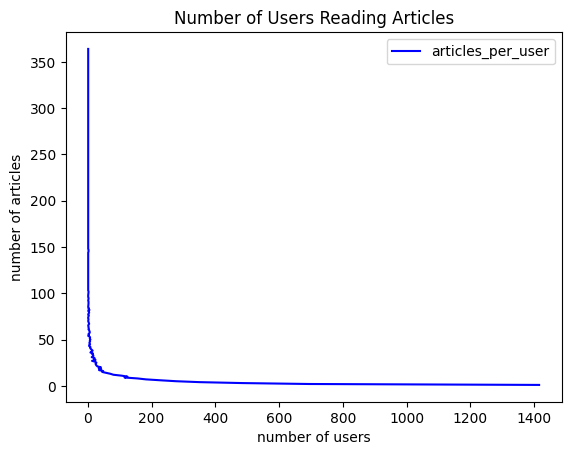

In [6]:
# Create a plot of the number of articles read by each user
# articles-per_user = df.groupby(['email'])['article_id'].size()
# Unique arrticles only:
articles_per_user = df.groupby(['email'])['article_id'].size()
users_by_articles = (
    articles_per_user
    .value_counts()
    .sort_index()
    .rename_axis("articles_per_user")
)

df_plot = users_by_articles.reset_index()
df_plot.columns = ['articles_per_user', 'num_users']

df_plot.plot(x='num_users', y='articles_per_user', kind='line', color='blue')

plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Number of Users Reading Articles')
plt.show()

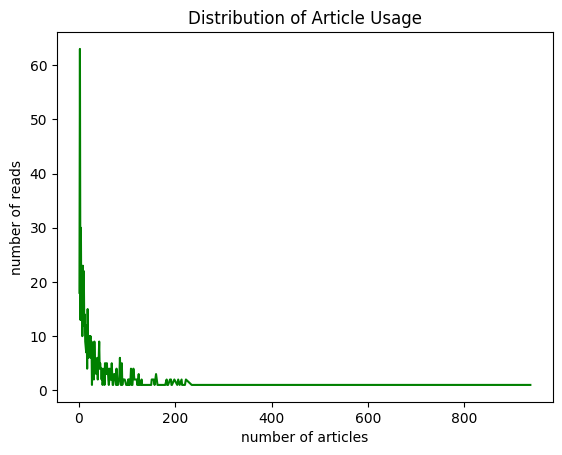

In [7]:
# Create a plot of the number of times each article was read
reads_per_article = df.groupby(['article_id'])['email'].size()
articles_by_readcount = (
    reads_per_article
    .value_counts()
    .sort_index()
    .rename_axis("reads_per_article")
    .rename("num_articles")
)

articles_by_readcount.plot(kind='line', color='green')

plt.xlabel('number of articles')
plt.ylabel('number of reads')
plt.title('Distribution of Article Usage')
plt.show()

In [8]:
# Fill in the median and maximum number of user_article interactions below

median_val = int(articles_per_user.median())
print(f"50% of individuals interact with {median_val} articles or fewer.")

max_views_by_user =  articles_per_user.sort_values(ascending=False).values[0]
print(f"The maximum number of user-article interactions by any 1 user is {max_views_by_user}.")

50% of individuals interact with 3 articles or fewer.
The maximum number of user-article interactions by any 1 user is 364.


`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [9]:
unique_articles =  len(df.article_id.unique())
print(f"The number of unique articles that have at least one interaction is {unique_articles}")

total_articles =  len(df.article_id.unique())
# This measure doesn't make sense since the dataset only contains interactions!
# We do not have data of articles without reads.
print(
    f"The number of unique articles on the IBM platform is {total_articles}. "
    "Attention, this measure is not valid since there is no data about non-read articles."
)

unique_users =  len(df.email.unique())
print(f"The number of unique users is {unique_users}")
user_article_interactions =  df.shape[0]
print(f"The number of user-article interactions is {user_article_interactions}")

# without re-reads:
unique_user_article_interactions = len(df.groupby(['article_id', 'email']).size())
print(f"The number of user-article interactions without re-reads is {unique_user_article_interactions}")

The number of unique articles that have at least one interaction is 714
The number of unique articles on the IBM platform is 714. Attention, this measure is not valid since there is no data about non-read articles.
The number of unique users is 5149
The number of user-article interactions is 45993
The number of user-article interactions without re-reads is 33682


`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [10]:
most_viewed_article_id = reads_per_article.sort_values(ascending=False).index[0]
print(
    f"The most viewed article in the dataset: ID {most_viewed_article_id} "
    f"- {df[df["article_id"]==int(most_viewed_article_id)].title.unique()[0]}."
)

max_views = reads_per_article.sort_values(ascending=False).values[0]
print(f"The most viewed article in the dataset was viewed {max_views} times.")


The most viewed article in the dataset: ID 1429 - use deep learning for image classification.
The most viewed article in the dataset was viewed 937 times.


In [11]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,article_id,title,user_id
0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1314,healthcare python streaming application demo,2
2,1429,use deep learning for image classification,3
3,1338,ml optimization using cognitive assistant,4
4,1276,deploy your python model as a restful api,5


In [12]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [13]:
a = [1,2,3]
a[:4]

[1, 2, 3]

In [14]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    reads_per_article = df.groupby(['title']).size()
    top_articles = reads_per_article.sort_values(ascending=False).index[:n]
    
    return top_articles # Return the top article titles from df

def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article IDs 
    
    """
    reads_per_article = df.groupby(['article_id']).size()
    top_articles = reads_per_article.sort_values(ascending=False).index[:n]
 
    return top_articles # Return the top article ids

In [15]:
print(get_top_articles(10))
print(get_top_article_ids(10))

Index(['use deep learning for image classification',
       'insights from new york car accident reports',
       'visualize car data with brunel',
       'use xgboost, scikit-learn & ibm watson machine learning apis',
       'predicting churn with the spss random tree algorithm',
       'healthcare python streaming application demo',
       'finding optimal locations of new store using decision optimization',
       'apache spark lab, part 1: basic concepts',
       'analyze energy consumption in buildings',
       'gosales transactions for logistic regression model'],
      dtype='object', name='title')
Index([1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304], dtype='int64', name='article_id')


In [16]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [17]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    # Fill in the function here
    df_unique = df.drop_duplicates(['user_id', 'article_id'])
    user_item = df_unique.groupby(['user_id', 'article_id']).size().unstack(fill_value=0)
    
    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

In [18]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [19]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    
    """
    
    # Unknown user_id: return all users with zero similarity
    if user_id not in user_item.index:
        if include_similarity:
            return [[u, 0.0] for u in user_item.index]
        return user_item.index
    
    # compute similarity of each user to the provided user
    cos_sim = cosine_similarity(user_item)
    idx = user_item.index.get_loc(user_id)
    scores = list(enumerate(cos_sim[idx]))

    # sort by similarity
    # remove the own user's id
    scores = sorted(scores, key=lambda x:x[1], reverse=True)[1:]
    
    # create list of just the ids
    sim_users = [i[0] for i in scores]
    
    # create list of just the similarities
    sims = [i[1] for i in scores]
    
    most_similar_users = user_item.index[sim_users]    
    if include_similarity:
        return [[a,b] for a,b in zip(most_similar_users, sims)]
    return most_similar_users # return a list of the users in order from most to least similar
        

In [21]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: Index([3933, 46, 4201, 253, 824, 5034, 5041, 136, 2305, 395], dtype='int64', name='user_id')
The 5 most similar users to user 3933 are: Index([1, 46, 4201, 253, 824], dtype='int64', name='user_id')
The 3 most similar users to user 46 are: Index([4201, 790, 5077], dtype='int64', name='user_id')


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [22]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """

    article_names = list(df[df.article_id.isin(article_ids)]['title'].unique())
    return article_names 

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) a list of article ids to evaluate (a subset to rank).
                the dtype should match the column labels in `user_item`.
    user_item - (pandas dataframe) a binary matrix of users by articles [n_users x n_articles]:
                1's when a user has interacted with an article, 0 otherwise 
                columns are article IDs.
    
    OUTPUT:
    ranked_article_unique_counts - (list) a list of tuples [(article_id, unique_user_count)]
                     only for the provided `article_ids` with article_id and number of unique
                     users that have interacted with the article, sorted by the number of unique
                     users in descending order
    
    Description:
    For each `article_id` in the input list, count the number of unique users who
    interacted with it (column sum in the binary `user_item` matrix).
    Return the (article_id, count) pairs sorted in descending order.
    """
    # Your code here
    user_item = user_item.transpose().loc[article_ids]
    user_item['sum'] = user_item.sum(axis=1)
    user_item = user_item.sort_values(["sum"], ascending= False)
    ranked_article_unique_counts = list(map(list, zip(user_item.index, user_item['sum'])))
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    # Your code here
    if user_id not in user_item.index:
        article_ids = []
        article_names= []
    else:
        user_item = user_item.transpose()
        article_ids = user_item.index[user_item[user_id]==1].tolist()  
        article_names = get_article_names(article_ids)
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    """
    # Your code here
    user_articles, user_article_names = get_user_articles(user_id)
    recs = []
    
    similar = find_similar_users(user_id)
    for sim_user in similar:
        sim_user_articles, sim_user_article_names = get_user_articles(sim_user)
        recs += list(set(sim_user_articles).difference(user_articles))
        if len(recs) >= m:
            break

    return recs[:m] # return your recommendations for this user_id    

In [23]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['analyze energy consumption in buildings',
 'analyze open data sets with pandas dataframes',
 'access mysql with r',
 'use sql with data in hadoop python',
 '15 page tutorial for r',
 'workflow in r',
 'awesome deep learning papers',
 'this week in data science (april 18, 2017)',
 'improving the roi of big data and analytics through leveraging new sources of data',
 'country statistics: airports']

In [24]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [25]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [26]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int)
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
    
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user
                    
    Other Details - sort the neighbors_df by the similarity and then by number of interactions where 
                    highest of each is higher in the dataframe, i.e. Descending order
     
    """
    # Your code here
    # Hint: find similar users, but include their similarity, from there we can find the number of interactions for each neighbor
    sim_users = find_similar_users(user_id, include_similarity=True)
    sim_user_ids = [x[0] for x in sim_users]
    interactions = user_item.loc[sim_user_ids].sum(axis=1).tolist()

    for i, extra in enumerate(interactions):        
        sim_users[i].append(extra)
    sim_users.sort(key=lambda x: (x[1], x[2], x[0]), reverse=True)
    
    neighbors_df = pd.DataFrame(sim_users)
    neighbors_df.columns = ['neighbor_id', 'similarity', 'num_interactions']
    neighbors_df['neighbor_id'] = neighbors_df['neighbor_id'].astype("Int64")
    neighbors_df['num_interactions'] = neighbors_df['num_interactions'].astype("Int64")
    
    return neighbors_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    * Choose the users that have the most total article interactions 
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions 
    before choosing those with fewer total interactions. 
   
    """

    user_articles, user_article_names = get_user_articles(user_id)
    recs = []
    
    similar = get_top_sorted_users(user_id).neighbor_id.tolist()
    for sim_user in similar:
        sim_user_articles, sim_user_article_names = get_user_articles(sim_user)

        sim_user_articles = get_ranked_article_unique_counts(sim_user_articles)

        sim_user_articles = list(map(lambda x: x[0], sim_user_articles))
        
        recs += list(set(sim_user_articles).difference(user_articles))
        if len(recs) >= m:
            break

    recs = recs[:m]
    
    
    return recs, get_article_names(recs) # return your recommendations for this user_id

In [27]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1185, 1165, 1293, 254, 1185, 1165, 1162, 1293, 1328, 1410]

The top 10 recommendations for user 20 are the following article names:
['classify tumors with machine learning', 'analyze energy consumption in buildings', 'uci: sms spam collection', 'income (2015): united states demographic measures', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'apple, ibm add machine learning to partnership with watson-core ml coupling']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [28]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
   neighbor_id  similarity  num_interactions
0         5083    0.730297                 5
1         1890    0.577350                 2
2         1552    0.577350                 2
3         1372    0.471405                 3
4         2941    0.433013                 8
5         3586    0.408248                 4
6         4897    0.408248                 1
7         3874    0.408248                 1
8         3630    0.408248                 1
9         3590    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1         4459    0.388909                96
2          203    0.388909                96
3         3782    0.387585               135
4         4932    0.384308                52
5           40    0.384308                52
6           23    0.377647               135
7          242    0.375823                59
8         

In [29]:
### Tests with a dictionary of results
user1_most_sim =  int(get_top_sorted_users(1).iloc[0].neighbor_id)
# Find the user that is most similar to user 1 
print(f"The user that is most similar to user 1: {user1_most_sim}.")
user2_6th_sim =  int(get_top_sorted_users(2).iloc[5].neighbor_id)
# Find the 6th most similar user to user 2
print(f"The user that is 6th most similar to user 2: {user2_6th_sim}.")
user131_10th_sim = int(get_top_sorted_users(131).iloc[9].neighbor_id)
# Find the 10th most similar user to user 131
print(f"The user that is the 10th most similar to user 131: {user131_10th_sim}.")

The user that is most similar to user 1: 3933.
The user that is 6th most similar to user 2: 3586.
The user that is the 10th most similar to user 131: 383.


In [30]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

### New user recommendation

New users would see recommendation based on the top read articles on the platform.
Although it would make sense to add topic related picks so we would have a wider variety of recommendations to new users.

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [31]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 

new_user_recs = get_top_article_ids(10)


In [32]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [33]:
df.head()

,article_id,title,user_id
0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1314,healthcare python streaming application demo,2
2,1429,use deep learning for image classification,3
3,1338,ml optimization using cognitive assistant,4
4,1276,deploy your python model as a restful api,5


In [34]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [35]:
# unique articles
df_unique_articles = df[["article_id", "title"]].drop_duplicates().reset_index()

In [36]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles.title) # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)  # Fit the LSA model to the vectorized article titles
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


Text(0.5, 0, 'Number of clusters')

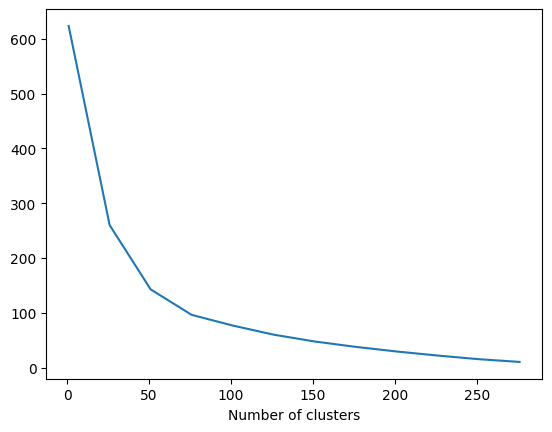

In [37]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [38]:
n_clusters = 50
kmeans = KMeans(
    n_clusters=n_clusters
).fit(X_tfidf)

In [39]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
article_cluster_map = dict(zip(df_unique_articles.article_id, kmeans.predict(X_tfidf))) # Map article_id to cluster label
df['title_cluster'] = df.article_id.map(article_cluster_map)

In [40]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[  0,  14],
       [  1,  27],
       [  2, 152],
       [  3,   5],
       [  4,   1],
       [  5,  20],
       [  6,  38],
       [  7,  20],
       [  8,  23],
       [  9,  20],
       [ 10,  16],
       [ 11,   6],
       [ 12,   6],
       [ 13,   9],
       [ 14,   7],
       [ 15,  14],
       [ 16,  18],
       [ 17,   6],
       [ 18,   6],
       [ 19,  18],
       [ 20,  22],
       [ 21,   9],
       [ 22,  10],
       [ 23,  30],
       [ 24,   5],
       [ 25,  15],
       [ 26,   3],
       [ 27,   9],
       [ 28,   4],
       [ 29,   5],
       [ 30,   6],
       [ 31,  10],
       [ 32,   5],
       [ 33,  18],
       [ 34,   4],
       [ 35,   6],
       [ 36,   7],
       [ 37,   9],
       [ 38,   8],
       [ 39,   7],
       [ 40,   9],
       [ 41,  19],
       [ 42,   7],
       [ 43,   7],
       [ 44,  15],
       [ 45,   5],
       [ 46,  13],
       [ 47,  12],
       [ 48,   4],
       [ 49,   5]])

In [41]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
    if article_id not in df.article_id:
        return [], []
    title_cluster = df[df.article_id == article_id].title_cluster.iloc[0]
    articles_in_cluster = df[df.title_cluster == title_cluster].article_id.unique().tolist()
    # remove the input article_id from the list
    articles_in_cluster.remove(article_id)
  
    return articles_in_cluster

In [42]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    if article_id not in df.article_id:
        return [], []
    similar_articles = get_similar_articles(article_id)
    ranked_sim_articles = get_ranked_article_unique_counts(similar_articles)

    n_ranked_similar_articles = [x[0] for x in ranked_sim_articles][:n]
    n_ranked_article_names = get_article_names(n_ranked_similar_articles)
    
    return n_ranked_similar_articles, n_ranked_article_names
        

In [43]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025, 237, 593, 821, 464, 29, 1042, 634, 693, 146]
['upload files to ibm data science experience using the command line', 'better together: spss and data science experience', 'experience iot with coursera', 'use ibm data science experience to read and write data stored on amazon s3', 'how to use db2 warehouse on cloud in data science experience notebooks', 'deep learning with data science experience', 'working with db2 warehouse on cloud in data science experience', 'data tidying in data science experience', 'using rstudio in ibm data science experience', 'use ibm data science experience to detect time series anomalies']


In [44]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

### Explanation of the recommendation system:

The function *make_content_recs* needs an input of an existing article. Based on the similarity of this article with other articles a recommendation is given. The recommendations are the highest read articles from the same similarity cluster.

The similarity is predicted entirely by the clusters defined based on the article names. It doesn't consider acual content or tags provided by the author. This is an area for improvement.

Additionally the recommendation doesn't consider possible other areas which might be interesting for the user. A mix with other recommendation mechanics might be helpful e.g. from time to time recommend articles from other areas with high user interactions. 



### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [45]:
# quick look at the matrix
user_item.head()

article_id,0,2,4,8,9,12,14,15,16,18,...,1434,1435,1436,1437,1439,1440,1441,1442,1443,1444
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [46]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

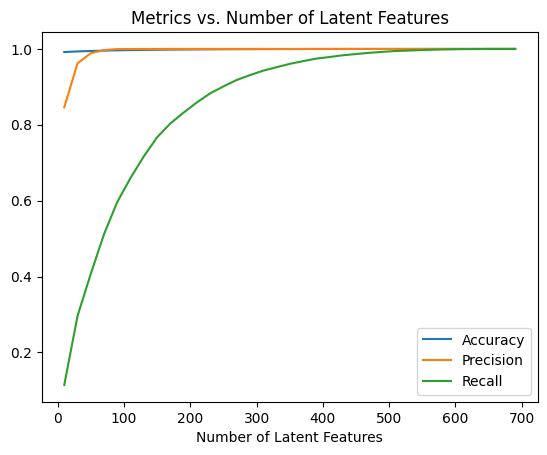

In [47]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

### Thoughts

Already with small amounts of latent features we are in an excelent range regarding our precision and recall values.
This points to overfitting since we are evaluating on the same data as the model was fitted on.

Since we see extreme values from the beginning I would not give any recommendation based on this graph but would suggest to do another run (see below).

Anyways, if forced to select a value I would go for a low amount of latent features like 50 to 100 to not run into extreme overfitting.



In [48]:
user_counts = user_item.sum(axis=1)
users_with_enough_ratings = user_counts[user_counts > 5].index.tolist()

print(f"Number of users with more than 5 articles read: {len(users_with_enough_ratings)}")

# Create a test set by randomly selecting 2 movies per user to include in our test set
user_item_test = df[df.user_id.isin(users_with_enough_ratings)].groupby("user_id").sample(2, random_state=42)
user_item_test = create_user_item_matrix(user_item_test)

user_item_test = user_item_test.reindex(
    index=user_item.index, columns=user_item.columns
)
user_item_test = user_item_test.convert_dtypes()
user_item_test = user_item_test.fillna(0)

user_item_train = user_item.copy()
user_item_train[user_item_test == 1] = 0

# Now that we have test set, we can create the train set by dropping the test indices from the sub_reviews_df
print(f"Train set size: {user_item_train.shape}")
print(f"Test set size: {user_item_test.shape}")

# Verify that the amount of entries of previous user_item is same as train + test
entries_correct = user_item_train.sum(axis=1).sum() + user_item_test.sum(axis=1).sum() == user_item.sum(axis=1).sum()
print(f"Entries in train + test equals user_item: {entries_correct}.")



Number of users with more than 5 articles read: 1660
Train set size: (5149, 714)
Test set size: (5149, 714)
Entries in train + test equals user_item: True.


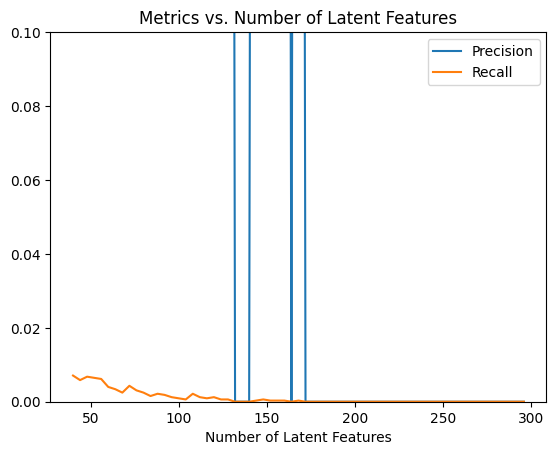

In [49]:
X_train = user_item_train.to_numpy()
X_test  = user_item_test.to_numpy()

num_latent_feats = np.arange(40, 300, 4)
prec_score = []
rec_score = []

for k in num_latent_feats:
    # fit SVD on training data
    svd_tts = TruncatedSVD(n_components=k, n_iter=5, random_state=42)
    U = svd_tts.fit_transform(X_train)
    Vt = svd_tts.components_

    # predict scores
    scores = U @ Vt

    # Convert to binary
    thresh = 0.5
    y_pred_matrix = (scores >= thresh).astype(int)

    # mask the positive data 
    test_mask = (X_test == 1)    
    y_true = X_test[test_mask].astype(int)
    y_pred = y_pred_matrix[test_mask].astype(int)


    # Evaluate on test data
    # acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    prec_score.append(prec)
    rec_score.append(rec)

plt.plot(num_latent_feats, prec_score, label=['Precision'])
plt.plot(num_latent_feats, rec_score, label=['Recall'])
plt.ylim(0, 0.1)
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')
plt.show()

Playing around with the values I could see that recall had good values but starts dropping after 50 latent features.

Precision is not usable at all since it is only 1 (predicted all 0 correctly) or 0 (mistake in predicition).

I am still not able to do a final decision on any value for the number of latent features. (Although I would lean towards 50).

Reading about the topic I got information about the ***Precision@10*** and ***Recall@10*** metrics.


In [50]:
def precision_recall_at_k(scores_row, test_items, k=10):
    """
    scores_row: 1D array of predicted scores for all items for a user
    test_items: set of item indices that belong to the test set for this user
    """
    # Get top‑k predicted items
    topk_items = np.argsort(scores_row)[-k:][::-1]  # sort descending

    # Count hits
    hits = sum(1 for item in topk_items if item in test_items)

    # Compute metrics
    precision = hits / k
    recall = hits / len(test_items) if len(test_items) > 0 else np.nan
    return precision, recall


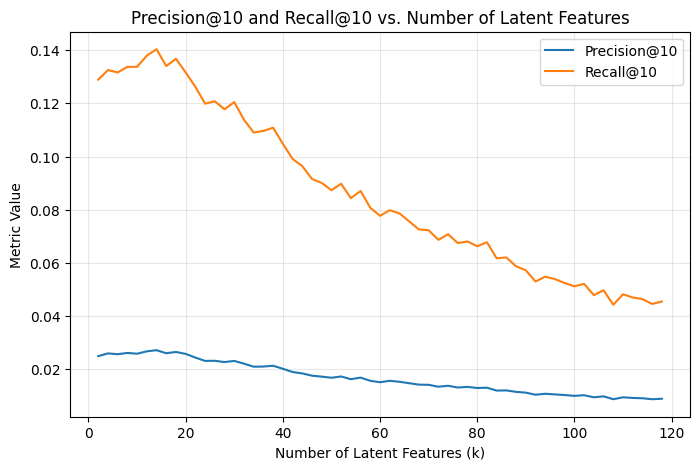

In [51]:
X_train = user_item_train.to_numpy()
X_test  = user_item_test.to_numpy()

num_users, num_items = X_train.shape

# Build per-user test item sets
test_sets = []
for u in range(num_users):
    test_sets.append(set(np.where(X_test[u] == 1)[0]))


num_latent_feats = np.arange(2, 120, 2)
precisions = []
recalls = []

for k in num_latent_feats:

    svd = TruncatedSVD(n_components=k, n_iter=7, random_state=42)
    U = svd.fit_transform(X_train)
    Vt = svd.components_

    scores = U @ Vt    # score matrix

    # Compute per‑user precision@10 and recall@10
    p_list = []
    r_list = []
    for u in range(num_users):
        test_items = test_sets[u]
        if len(test_items) == 0:
            continue  # skip users without test positives
        
        p, r = precision_recall_at_k(scores[u], test_items, k=10)
        p_list.append(p)
        r_list.append(r)

    precisions.append(np.nanmean(p_list))
    recalls.append(np.nanmean(r_list))


# ---------------------------------------------------------
# PLOT RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(num_latent_feats, precisions, label='Precision@10')
plt.plot(num_latent_feats, recalls, label='Recall@10')
plt.xlabel("Number of Latent Features (k)")
plt.ylabel("Metric Value")
plt.title("Precision@10 and Recall@10 vs. Number of Latent Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Conclusion on Latent Features

Based on the analysis with the ***Precision@10*** and ***Recall@10*** metrics I would suggest the number of latent features to be **16**.

Although what we see here is not a textbook behavior of the two metrics this might be connected with sparse data and usage of a simple SVD.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [52]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    # Find the index of the article_id
    if article_id not in user_item.columns:
        if include_similarity:
            return [], []
        return []
    
    
    article_idx = user_item.columns.get_loc(article_id)
        
    # Find the cosine similarity of all articles
    # Hint: vt should be transposed before passing to cosine_similarity to get a 714 x 714 matrix 
    cos_sim = cosine_similarity(vt_new.transpose(), vt_new.transpose())
    
    # Get similarities only for the cos_sim of the article_idx
    scores = list(enumerate(cos_sim[article_idx]))
    
    # Sort and return the articles, don't include the own article
    scores = sorted(scores, key=lambda x:x[1], reverse=True)[1:]
    
    # create list of just the ids
    sim_article_idx = [i[0] for i in scores]

    # create list of just the similarities
    sims = [i[1] for i in scores]

    most_sim_articles = [user_item.columns[i] for i in sim_article_idx]
    if include_similarity:
        return [[a,b] for a,b in zip(most_sim_articles, sims)]
    return most_sim_articles

In [53]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [54]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [55]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[np.int64(1199),
 np.int64(1068),
 np.int64(486),
 np.int64(1202),
 np.int64(176),
 np.int64(1120),
 np.int64(244),
 np.int64(793),
 np.int64(58),
 np.int64(132)]

In [56]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['use spark r to load and analyze data',
 'collecting data science cheat sheets',
 '10 powerful features on watson data platform, no coding necessary',
 'notebooks: a power tool for data scientists',
 'country statistics: crude oil - proved reserves',
 'country statistics: crude oil - exports',
 'top analytics tools in 2016',
 'advancements in the spark community',
 'airbnb data for analytics: paris calendar',
 'airbnb data for analytics: athens reviews']

In [57]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

### Evaluation of different recommendation methods

To determine effectiveness of our promotion systems we could run different recommendation systems for different users and monitor their reading behavior over several months.

Split of users:
- We will split users in groups based on their similarity 
- Users within a group are then randomly distributed to different recommendation systems.
- New users are not considered, we do not have a choice of recommendation systems for them
  - If we had we would count new users as one group

Run of the Experiment:
- 2-3 months
- if major holidays are in the duration these need to be reflected differently

Metrics to be collected:
- Click-through Rate (CTR): Measure how often users click on recommendations
- User Activity Rate: Measure activitiy of users, increase or decrease
- if new users are considered: Conversion Rate initial signup to regular reader

Compare the selected metrics during the measurement. If no major issues are encvountered run the experiment the whole duration.
After the complete experiment duration analyze the outcome of different metrics and choose the next steps.

Additional options for the platform would be to implement an article rating and analyze impact of rating development of recommended articles.
  

### Reflection on different recommendation methods

Which recommendation system promotes more clicks/reads of recommended articles? Which recommendation system has the highest reader retention?

A combination of predictive systems might further improve the quality.

- Part II: Rank-Based Recommendations
  - Recommendation based on articles with the highest number of reads.
  - This is a good way to promote articles to completely new users where we do not have any prior knowledge about.
  - For a real recommendation system this should still be combined with topics/similarity so that we propose articles for a variety of topics to a new user. Otherwise we could face leaving customers if no topic of interest is in the recommendations.
- Part III: User-User Based Collaborative Filtering
  - Recommendation of reads by users with similar preferences
  - This is a great system for long time users and users with a mix of interests.
  - Currently we are only focusing on the reads of the top similar user before moving to the next. Promoting reads from each of the top n similar users might be benefitial to promote articles from different topics.
- Part IV: Content Based Recommendations
  - Recommendations by clusters calculated with KMeans
  - This is a great system for newer users where we have first information about their preferences.
  - Currently the promotion is only considering similarity to one article, not other articles from the user's history. It might be helpful to add this feature to promote other articles of possible interst to the user
  - Similarity clusters are currently only calculated based on title, this needs to be improved based on content like tags
- Section V - Matrix Factorization
  - Recommendation based on predictions calculated with a SVD
  - This would be a good way to get recommendations if we had a much bigger dataset and more reads per user. Currently the data is not sufficient to get a good predictive system

All recommendation systems have in common that (beside the similarity) we focus on amount of reads and no other factor in the ranking. This would lead to promotion of old articles whilst users might be more interested in newer articles. Inclusion of a "hot and trending" metric to promote new interesting articles is stringly recommended.


<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [58]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Recommendations_with_IBM.ipynb'])

1